In [96]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from datetime import timedelta
from pathlib import Path
from mlforecast import MLForecast
import seaborn as sns
import matplotlib.pyplot as plt
import config
from src.data.reader import read_parquet_pl
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)

In [97]:
import importlib
import config
import config.features
importlib.reload(config.features)
importlib.reload(config)

<module 'config' from '/home/njimenez/workspace/magister/forecast-tfm/notebooks/../config/__init__.py'>

In [98]:
!ls ../data/processed/

dataset_level_01_daily_total.parquet
dataset_level_01_daily_w1y_total.parquet
dataset_level_01_daily_w2y_total.parquet
dataset_level_01_daily_w3y_total.parquet
dataset_level_01_daily_wmax_total.parquet
dataset_level_01_weekly_w3y_total.parquet
dataset_level_01_weekly_w4y_total.parquet
dataset_level_01_weekly_wmax_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_02_daily_w1y_state.parquet
dataset_level_02_daily_w2y_state.parquet
dataset_level_02_daily_w3y_state.parquet
dataset_level_02_daily_wmax_state.parquet
dataset_level_02_weekly_w3y_state.parquet
dataset_level_02_weekly_w4y_state.parquet
dataset_level_02_weekly_wmax_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_03_daily_w1y_cat.parquet
dataset_level_03_daily_w2y_cat.parquet
dataset_level_03_daily_w3y_cat.parquet
dataset_level_03_daily_wmax_cat.parquet
dataset_level_03_weekly_w3y_cat.parquet
dataset_level_03_weekly_w4y_cat.parquet
dataset_level_03_weekly_wmax_cat.parquet
dataset_level_04_daily_dept.p

In [99]:
!ls ../artifacts/models/

mlf_level_01_daily_w1y_total	    mlf_level_07_daily_w1y_state_dept
mlf_level_01_daily_w2y_total	    mlf_level_07_daily_w2y_state_dept
mlf_level_01_daily_w3y_total	    mlf_level_07_daily_w3y_state_dept
mlf_level_01_daily_wmax_total	    mlf_level_07_daily_wmax_state_dept
mlf_level_01_weekly_w3y_total	    mlf_level_07_weekly_w3y_state_dept
mlf_level_01_weekly_w4y_total	    mlf_level_07_weekly_w4y_state_dept
mlf_level_01_weekly_wmax_total	    mlf_level_07_weekly_wmax_state_dept
mlf_level_02_daily_w1y_state	    mlf_level_08_daily_w1y_store_cat
mlf_level_02_daily_w2y_state	    mlf_level_08_daily_w2y_store_cat
mlf_level_02_daily_w3y_state	    mlf_level_08_daily_w3y_store_cat
mlf_level_02_daily_wmax_state	    mlf_level_08_daily_wmax_store_cat
mlf_level_02_weekly_w3y_state	    mlf_level_08_weekly_w3y_store_cat
mlf_level_02_weekly_w4y_state	    mlf_level_08_weekly_w4y_store_cat
mlf_level_02_weekly_wmax_state	    mlf_level_08_weekly_wmax_store_cat
mlf_level_03_daily_w1y_cat	    mlf_level_09_daily

# Modelo

# Cargar Modelo

In [100]:
# ── Elige el nivel a estudiar ──────────────────────────────────────────────
LEVEL_NAME = "item"   # total | state | cat | dept | store | state_cat | ...
GRAIN      = "daily"        # "daily" | "weekly"
WINDOW     = "w2y"          # "w1y" | "w2y" | "w3y" | "w4y" | "wmax"

# ── Rutas ──────────────────────────────────────────────────────────────────
# algunos niveles guardan el parquet con window en el nombre (p.ej. daily/item_store),
# otros sin window (p.ej. weekly/item_store); se prueba con window primero
_parquets = sorted(Path("../data/processed").glob(f"dataset_level_*_{GRAIN}_{WINDOW}_{LEVEL_NAME}.parquet"))
if not _parquets:
    _parquets = sorted(Path("../data/processed").glob(f"dataset_level_*_{GRAIN}_{LEVEL_NAME}.parquet"))

_models = sorted(Path("../artifacts/models").glob(f"mlf_*_{GRAIN}_{WINDOW}_{LEVEL_NAME}"))

if not _parquets:
    available = sorted(Path("../data/processed").glob(f"dataset_level_*_{LEVEL_NAME}.parquet"))
    raise FileNotFoundError(
        f"No hay parquet {GRAIN!r}/{WINDOW!r} para '{LEVEL_NAME}'.\n"
        f"Disponibles: {[p.name for p in available]}"
    )
if not _models:
    available = sorted(Path("../artifacts/models").glob(f"mlf_*_{LEVEL_NAME}"))
    raise FileNotFoundError(
        f"No hay modelo {GRAIN!r}/{WINDOW!r} para '{LEVEL_NAME}'.\n"
        f"Disponibles: {[m.name for m in available]}"
    )

file      = _parquets[0]
model_dir = _models[0]
print(f"Parquet : {file.name}")
print(f"Modelo  : {model_dir.name}")

Parquet : dataset_level_10_daily_w2y_item.parquet
Modelo  : mlf_level_10_daily_w2y_item


In [101]:
# ── Carga y split temporal ─────────────────────────────────────────────────
_raw       = read_parquet_pl(file).rename({"agg_id": "unique_id", "date": "ds", "sales": "y"})

horizon    = 28          # el horizonte que quieres estudiar
h_max      = max(config.HORIZON[GRAIN])   # 42 — con el que se entrenó

delta_days = h_max * 7 if GRAIN == "weekly" else h_max   # ← usar h_max, no horizon
cutoff     = _raw["ds"].max() - timedelta(days=delta_days)
valid_pl   = _raw.filter(pl.col("ds") > cutoff)          # ahora son 42 días

# ── Exog futuras (igual que en entrenamiento) ──────────────────────────────
exog_cols   = [config.PRICE_LAG_COL[GRAIN]] + config.EXOG_COLS
avail_exog  = [c for c in exog_cols if c in valid_pl.columns]
future_exog = valid_pl.select(["unique_id", "ds"] + avail_exog).to_pandas()

In [102]:
# ── Predicción ─────────────────────────────────────────────────────────────
fcst = MLForecast.load(str(model_dir))

# make_future_dataframe gives the exact (unique_id, ds) skeleton the model expects;
# left-join exog features onto it so no combination is missing
future_skeleton = fcst.make_future_dataframe(h=horizon)
future_exog_full = future_skeleton.merge(future_exog, on=["unique_id", "ds"], how="left")

preds_df = fcst.predict(h=horizon, X_df=future_exog_full)

# ── df con predicciones ───────────────────────────────────────────────────
dim_cols = [c for c in valid_pl.columns if c.endswith("_id") and c != "unique_id"]

df = (
    valid_pl.select(["unique_id", "ds", "y"] + dim_cols)
    .to_pandas()
    .rename(columns={"unique_id": "agg_id", "ds": "date", "y": "sales"})
    .merge(
        preds_df[["unique_id", "ds", "lgb"]].rename(
            columns={"unique_id": "agg_id", "ds": "date", "lgb": "forecast"}
        ),
        on=["agg_id", "date"],
    )
)

df["sales"] = df["sales"].round().astype("int64")
df["forecast"] = df["forecast"].round().astype("int64")

df["error"]     = df["sales"] - df["forecast"]
df["abs_error"] = df["error"].abs()

ordered_cols = [
    "agg_id",
    "state_id",
    "store_id",
    "cat_id",
    "dept_id",
    "item_id",
    "date",
    "sales",
    "forecast",
    "error",
    "abs_error",
]

df = df[ordered_cols]

df.head()

/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_m

,agg_id,state_id,store_id,cat_id,dept_id,item_id,date,sales,forecast,error,abs_error
0,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-11,8,6,2,2
1,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-12,0,0,0,0
2,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-13,6,7,-1,1
3,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-14,3,5,-2,2
4,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-15,4,6,-2,2


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85372 entries, 0 to 85371
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   agg_id     85372 non-null  str           
 1   state_id   85372 non-null  str           
 2   store_id   85372 non-null  str           
 3   cat_id     85372 non-null  str           
 4   dept_id    85372 non-null  str           
 5   item_id    85372 non-null  str           
 6   date       85372 non-null  datetime64[ms]
 7   sales      85372 non-null  int64         
 8   forecast   85372 non-null  int64         
 9   error      85372 non-null  int64         
 10  abs_error  85372 non-null  int64         
dtypes: datetime64[ms](1), int64(4), str(6)
memory usage: 12.8 MB


In [104]:
df.value_counts('agg_id')

agg_id
FOODS_1_FOODS_FOODS_1_001                28
FOODS_1_FOODS_FOODS_1_002                28
FOODS_1_FOODS_FOODS_1_003                28
FOODS_1_FOODS_FOODS_1_004                28
FOODS_1_FOODS_FOODS_1_005                28
                                         ..
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_512    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_513    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_514    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_515    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516    28
Name: count, Length: 3049, dtype: int64

In [105]:
df.value_counts('date')

date
2016-04-11    3049
2016-04-12    3049
2016-04-13    3049
2016-04-14    3049
2016-04-15    3049
2016-04-16    3049
2016-04-17    3049
2016-04-18    3049
2016-04-19    3049
2016-04-20    3049
2016-04-21    3049
2016-04-22    3049
2016-04-23    3049
2016-04-24    3049
2016-04-25    3049
2016-04-26    3049
2016-04-27    3049
2016-04-28    3049
2016-04-29    3049
2016-04-30    3049
2016-05-01    3049
2016-05-02    3049
2016-05-03    3049
2016-05-04    3049
2016-05-05    3049
2016-05-06    3049
2016-05-07    3049
2016-05-08    3049
Name: count, dtype: int64

# Exploracion

In [106]:
def analyze_agg(df: pd.DataFrame, group_by: list[str] | None = None) -> pd.DataFrame:
    if group_by is None:
        group_by = ["agg_id"] + [
            c for c in df.columns
            if c.endswith("_id") and c != "agg_id"
        ]

    def agg_fn(g: pd.DataFrame) -> pd.Series:
        active_mask = g["sales"] > 0
        sales_active = g.loc[active_mask, "sales"]
        sales_dates = g.loc[active_mask, "date"]

        sales_sum = g["sales"].sum()
        error_sum = g["error"].sum()
        abs_error_sum = g["abs_error"].sum()

        first_sale = sales_dates.min() if not sales_dates.empty else pd.NaT
        last_sale = sales_dates.max() if not sales_dates.empty else pd.NaT

        active_periods = int(active_mask.sum())
        available_periods = (
            int((g["date"] >= first_sale).sum()) if pd.notna(first_sale) else 0
        )

        adi = available_periods / active_periods if active_periods else np.nan
        cv2 = (sales_active.std() / sales_active.mean()) ** 2 if active_periods > 1 else np.nan

        return pd.Series({
            "n_obs": len(g),
            "sales_sum": sales_sum,
            "forecast_sum": g["forecast"].sum(),
            "rmse": np.sqrt((g["error"] ** 2).mean()),
            "first_sale": first_sale,
            "last_sale": last_sale,
            "available_periods": available_periods,
            "active_periods": active_periods,
            "avg_sale_when_active": sales_active.mean() if active_periods else np.nan,
            "adi": adi,
            "cv2": cv2,
            "wape": abs_error_sum / abs(sales_sum) if sales_sum else np.nan,
            "bias": -error_sum / abs(sales_sum) if sales_sum else np.nan,
        })

    result = (
        df.groupby(group_by)
        .apply(agg_fn, include_groups=False)
        .reset_index()
    )

    result["demand_type"] = np.select(
        [
            (result["adi"] < 1.32) & (result["cv2"] < 0.49),
            (result["adi"] < 1.32) & (result["cv2"] >= 0.49),
            (result["adi"] >= 1.32) & (result["cv2"] < 0.49),
            (result["adi"] >= 1.32) & (result["cv2"] >= 0.49),
        ],
        ["smooth", "erratic", "intermittent", "lumpy"],
        default="unknown",
    )

    #result["sale_span_days"] = (result["last_sale"] - result["first_sale"]).dt.days
    result['available_ratio'] = result["available_periods"] / result["n_obs"]
    result["active_ratio"] = result["active_periods"] / result["n_obs"]

    return result.sort_values(group_by).reset_index(drop=True)

In [107]:
def plot_agg_id_forecast(df, agg_id=None):
    if agg_id is None:
        agg_id = df["agg_id"].sample(1).iloc[0]

    s = (
        df[df["agg_id"] == agg_id]
        .sort_values("date")
        .copy()
    )

    if s.empty:
        raise ValueError(f"agg_id '{agg_id}' no existe en el df.")

    dates = s["date"].to_numpy()
    sales = s["sales"].to_numpy()
    forecast = s["forecast"].to_numpy()

    meta = s.iloc[0].to_dict()

    dim_info = {
        k: v
        for k, v in meta.items()
        if k.endswith("_id")
        and k != "agg_id"
        and pd.notna(v)
    }

    subtitle = " | ".join(
        f"{k.replace('_id', '')}: {v}"
        for k, v in dim_info.items()
    )

    denom = np.abs(sales).sum()
    wape = np.abs(sales - forecast).sum() / denom if denom else np.nan
    bias = (forecast - sales).sum() / denom if denom else np.nan

    fig, ax = plt.subplots(figsize=(15, 6))

    fig.suptitle(
        f"agg_id: {agg_id} | WAPE: {wape:.1%} | Bias: {bias:.1%}",
        fontsize=13,
    )

    if subtitle:
        ax.set_title(subtitle, fontsize=10)

    ax.plot(
        dates,
        sales,
        marker="o",
        label="Real",
    )

    ax.plot(
        dates,
        forecast,
        marker="o",
        linestyle="--",
        label="Forecast",
    )

    ax.set_ylabel("Ventas")

    ymax = max(sales.max(), forecast.max())
    ax.set_ylim(0, ymax * 1.1 if ymax > 0 else 1)

    ax.legend()
    ax.grid(alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    if GRAIN == 'daily':
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [108]:
df_summary = analyze_agg(df)

df_summary.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio
0,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,28,175,155,5.405024,2016-04-11,2016-05-08,28,27,6.481481,1.037037,0.793537,0.514286,-0.114286,erratic,1.000000,0.964286
1,FOODS_1_FOODS_FOODS_1_002,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_002,28,118,97,2.129722,2016-04-11,2016-05-08,28,28,4.214286,1.000000,0.214200,0.364407,-0.177966,smooth,1.000000,1.000000
2,FOODS_1_FOODS_FOODS_1_003,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_003,28,156,167,3.005946,2016-04-11,2016-05-08,28,28,5.571429,1.000000,0.347043,0.442308,0.070513,smooth,1.000000,1.000000
3,FOODS_1_FOODS_FOODS_1_004,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_004,28,1476,1283,27.665734,2016-04-26,2016-05-08,13,13,113.538462,1.000000,0.180948,0.332656,-0.130759,smooth,0.464286,0.464286
4,FOODS_1_FOODS_FOODS_1_005,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_005,28,546,533,8.117442,2016-04-11,2016-05-08,28,28,19.500000,1.000000,0.153992,0.357143,-0.023810,smooth,1.000000,1.000000


In [109]:
df_summary['bias_abs'] = df_summary['bias'].abs()

df_summary = df_summary.sort_values("wape")
df_summary = df_summary.dropna()
df_summary.head(10)

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio,bias_abs
1306,FOODS_3_FOODS_FOODS_3_694,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_694,28,5769,5525,18.214986,2016-04-11,2016-05-08,28,28,206.035714,1.0,0.020199,0.071416,-0.042295,smooth,1.0,1.0,0.042295
1198,FOODS_3_FOODS_FOODS_3_586,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_586,28,11515,11242,36.995656,2016-04-11,2016-05-08,28,28,411.250000,1.0,0.027258,0.078246,-0.023708,smooth,1.0,1.0,0.023708
732,FOODS_3_FOODS_FOODS_3_120,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_120,28,7469,7243,31.511903,2016-04-11,2016-05-08,28,28,266.750000,1.0,0.024928,0.089436,-0.030258,smooth,1.0,1.0,0.030258
1070,FOODS_3_FOODS_FOODS_3_458,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_458,28,2821,2804,12.613768,2016-04-11,2016-05-08,28,28,100.750000,1.0,0.030800,0.098192,-0.006026,smooth,1.0,1.0,0.006026
1123,FOODS_3_FOODS_FOODS_3_511,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_511,28,2607,2537,12.351981,2016-04-11,2016-05-08,28,28,93.107143,1.0,0.046085,0.099731,-0.026851,smooth,1.0,1.0,0.026851
838,FOODS_3_FOODS_FOODS_3_226,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_226,28,5248,5299,23.640915,2016-04-11,2016-05-08,28,28,187.428571,1.0,0.032828,0.102325,0.009718,smooth,1.0,1.0,0.009718
864,FOODS_3_FOODS_FOODS_3_252,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_252,28,7916,8142,38.728911,2016-04-11,2016-05-08,28,28,282.714286,1.0,0.066040,0.104598,0.028550,smooth,1.0,1.0,0.028550
989,FOODS_3_FOODS_FOODS_3_377,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_377,28,3758,3629,17.278186,2016-04-11,2016-05-08,28,28,134.214286,1.0,0.027212,0.106173,-0.034327,smooth,1.0,1.0,0.034327
692,FOODS_3_FOODS_FOODS_3_080,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_080,28,3046,3041,13.717819,2016-04-11,2016-05-08,28,28,108.785714,1.0,0.035342,0.108667,-0.001641,smooth,1.0,1.0,0.001641
1309,FOODS_3_FOODS_FOODS_3_697,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_697,28,1808,1869,8.533547,2016-04-11,2016-05-08,28,28,64.571429,1.0,0.048206,0.112279,0.033739,smooth,1.0,1.0,0.033739


In [110]:
df_summary.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio,bias_abs
1306,FOODS_3_FOODS_FOODS_3_694,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_694,28,5769,5525,18.214986,2016-04-11,2016-05-08,28,28,206.035714,1.0,0.020199,0.071416,-0.042295,smooth,1.0,1.0,0.042295
1198,FOODS_3_FOODS_FOODS_3_586,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_586,28,11515,11242,36.995656,2016-04-11,2016-05-08,28,28,411.250000,1.0,0.027258,0.078246,-0.023708,smooth,1.0,1.0,0.023708
732,FOODS_3_FOODS_FOODS_3_120,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_120,28,7469,7243,31.511903,2016-04-11,2016-05-08,28,28,266.750000,1.0,0.024928,0.089436,-0.030258,smooth,1.0,1.0,0.030258
1070,FOODS_3_FOODS_FOODS_3_458,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_458,28,2821,2804,12.613768,2016-04-11,2016-05-08,28,28,100.750000,1.0,0.030800,0.098192,-0.006026,smooth,1.0,1.0,0.006026
1123,FOODS_3_FOODS_FOODS_3_511,TOTAL,TOTAL,FOODS,FOODS_3,FOODS_3_511,28,2607,2537,12.351981,2016-04-11,2016-05-08,28,28,93.107143,1.0,0.046085,0.099731,-0.026851,smooth,1.0,1.0,0.026851


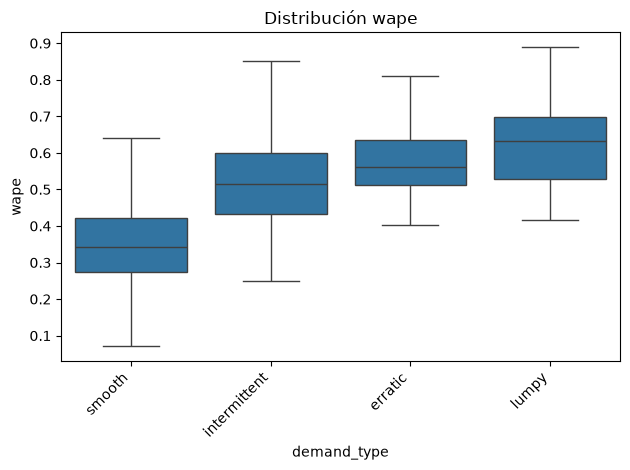

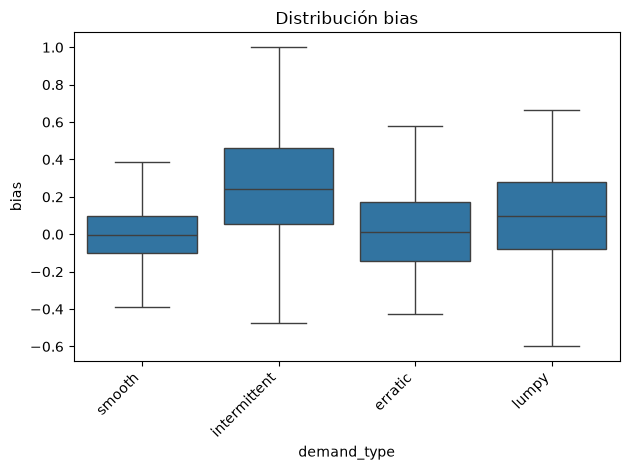

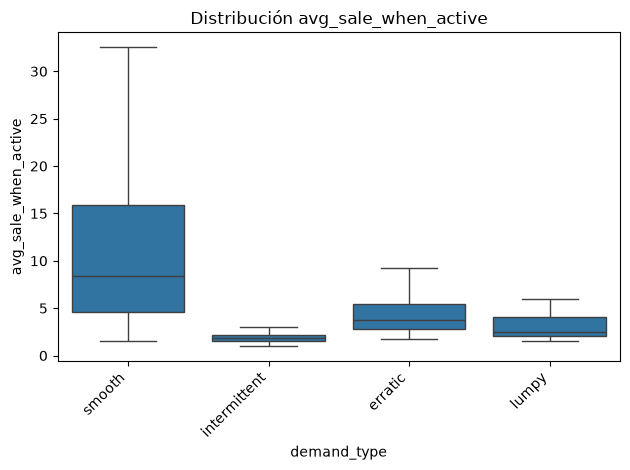

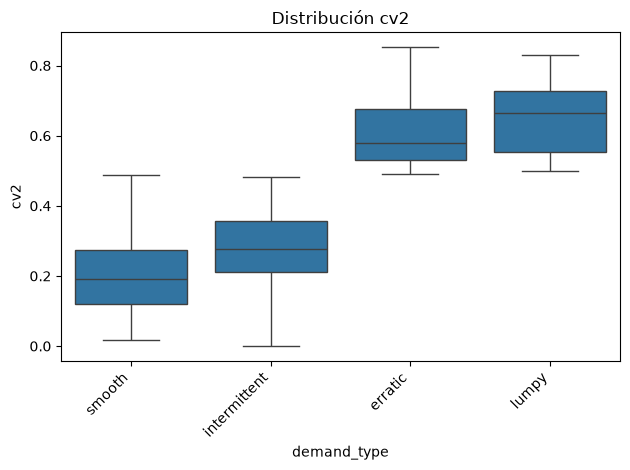

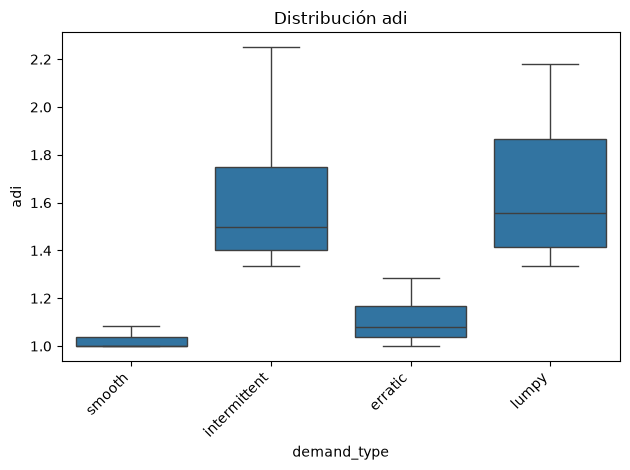

In [120]:
def plot_metric(df, by, metric='wape'):
    sns.boxplot(
        data=df.query("available_ratio >= 0.85"),
        x=by,
        y=metric,
        showfliers=False,
    )

    plt.title(f"Distribución {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in ['demand_type']:
    plot_metric(df_summary, col)
    plot_metric(df_summary, col, metric='bias')
    plot_metric(df_summary, col, metric='avg_sale_when_active')
    plot_metric(df_summary, col, metric='cv2')
    plot_metric(df_summary, col, metric='adi')

In [121]:
df_summary.query("available_ratio >= 0.85").groupby(['demand_type'])[['avg_sale_when_active','wape', 'bias','adi', 'cv2']].median().round(2)

,avg_sale_when_active,wape,bias,adi,cv2
demand_type,,,,,
erratic,3.80,0.56,0.01,1.08,0.58
intermittent,1.85,0.52,0.24,1.50,0.28
lumpy,2.44,0.63,0.10,1.56,0.66
smooth,8.39,0.34,-0.01,1.00,0.19


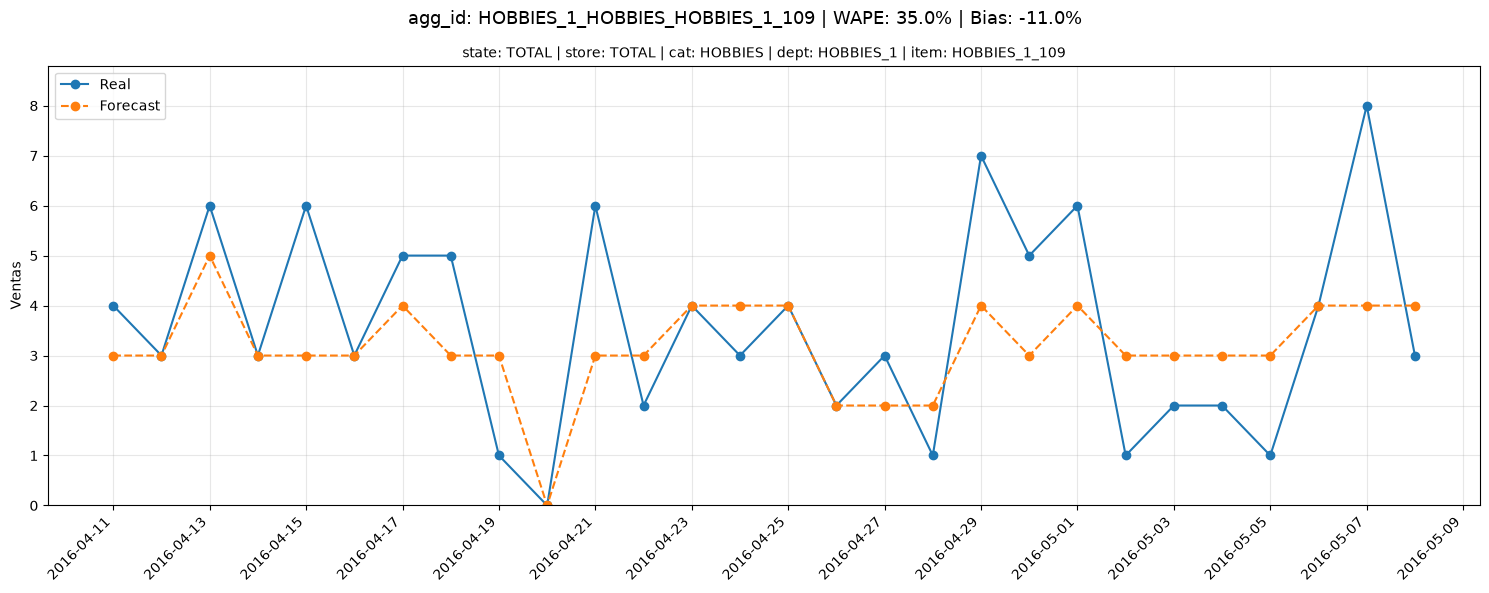

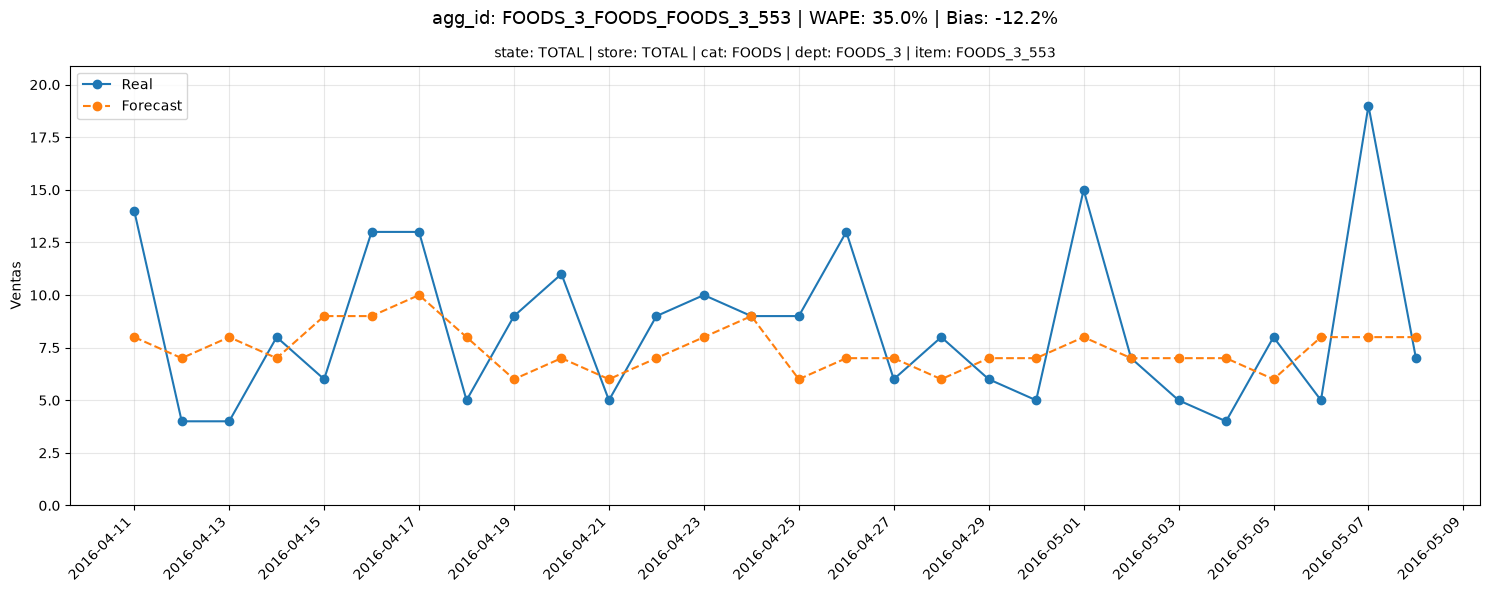

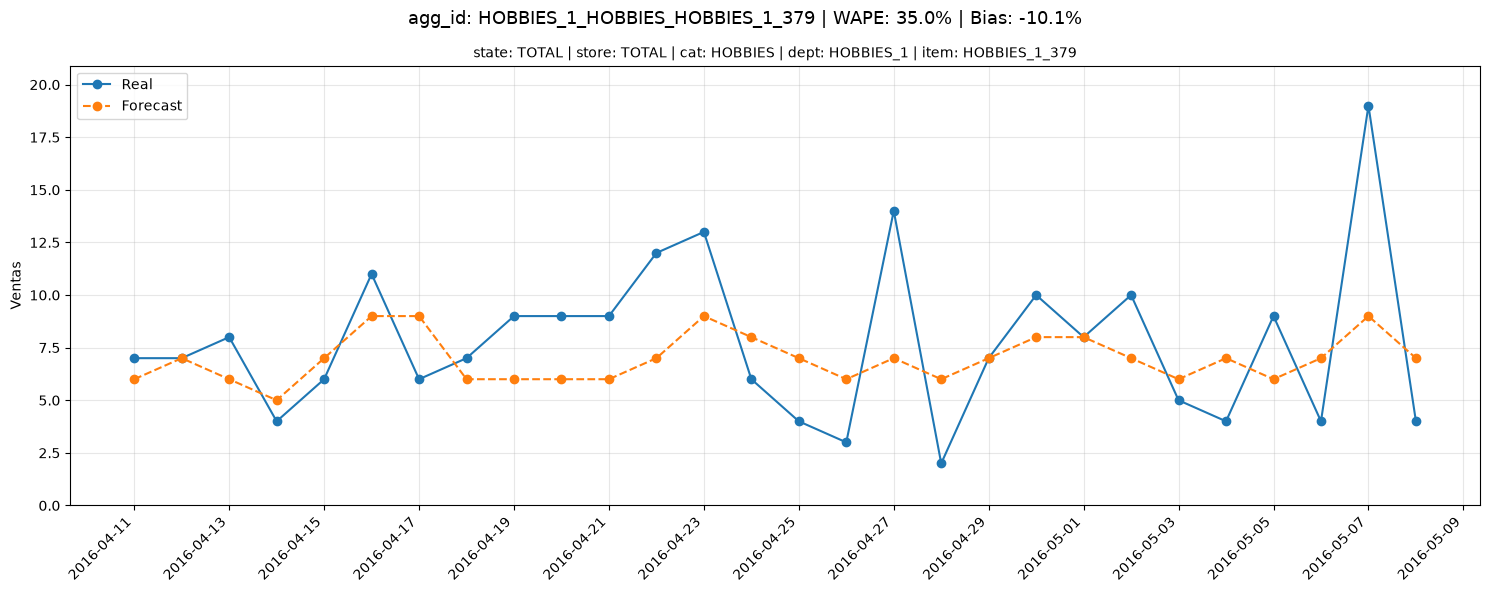

In [122]:
for id in df_summary.query('wape >= 0.35 and bias_abs <= 0.15 and available_ratio >= 0.8')['agg_id'].head(3):
    plot_agg_id_forecast(df, id)

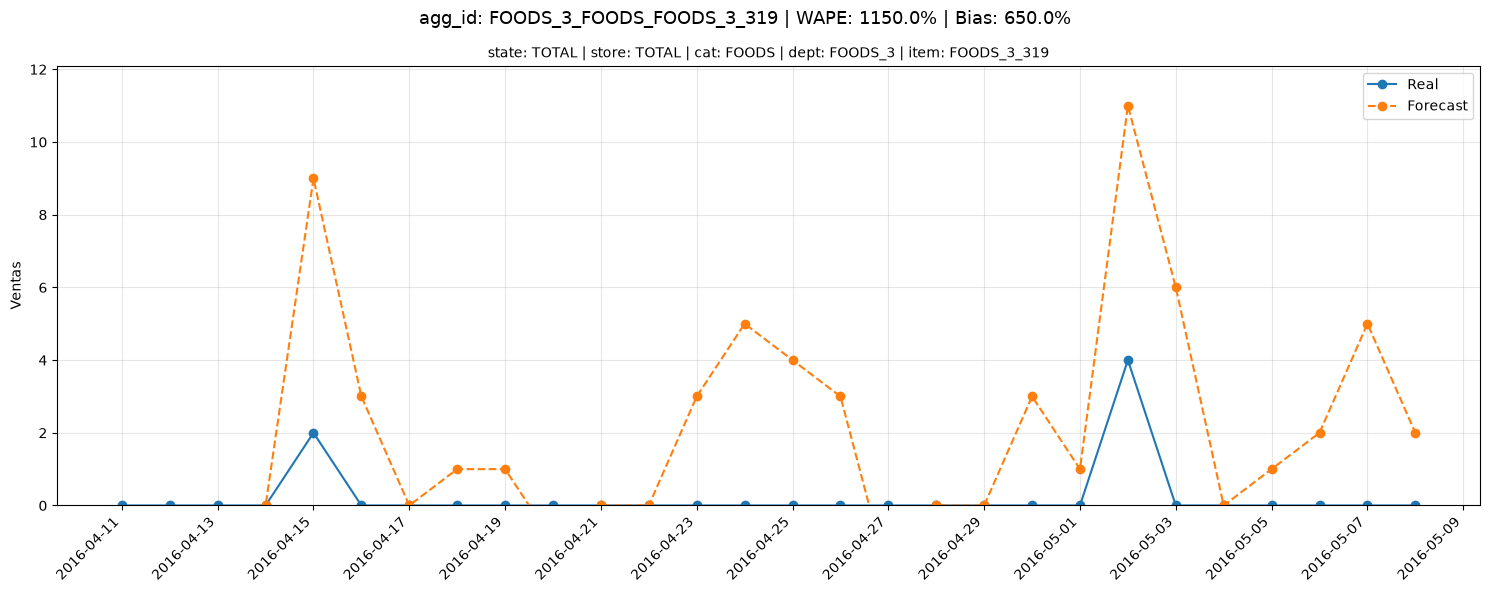

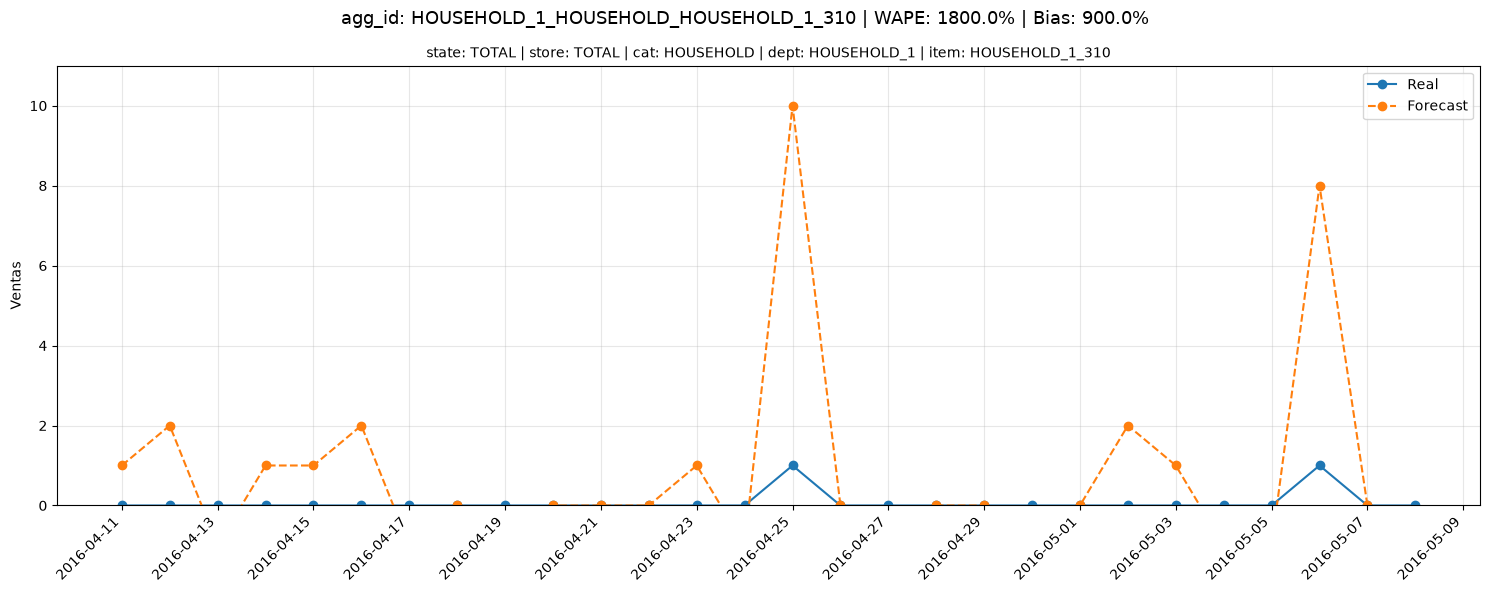

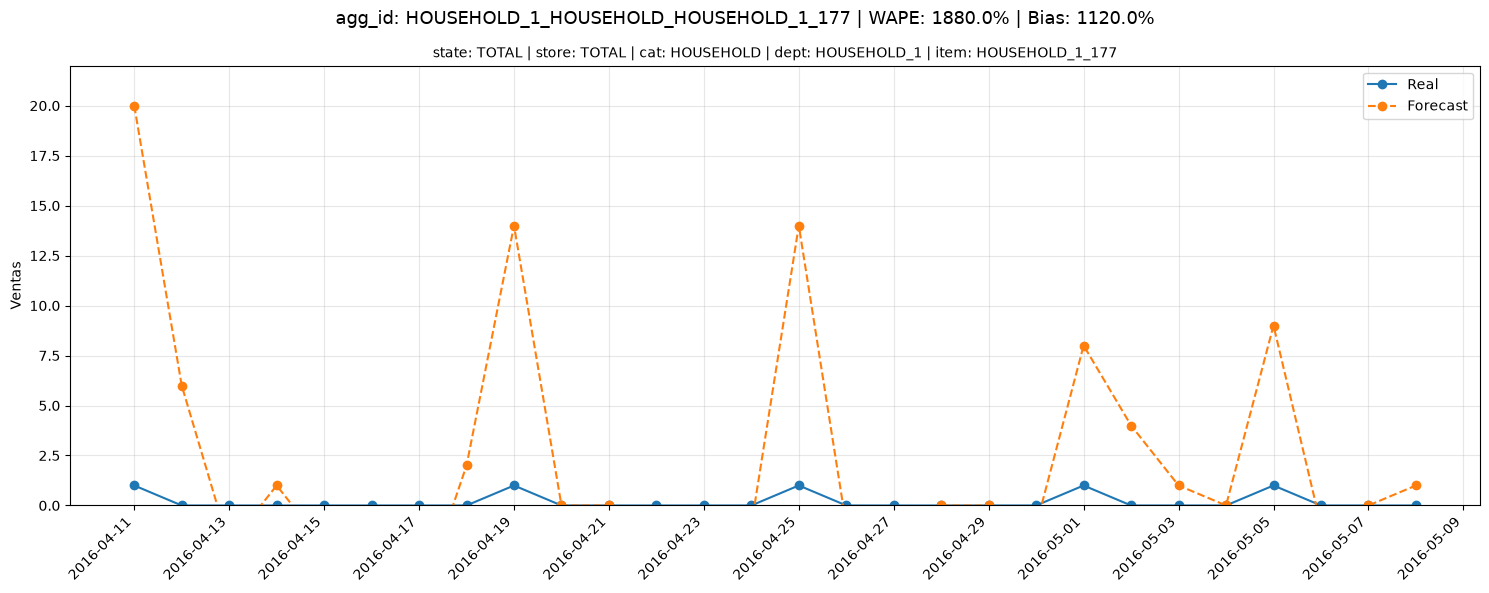

In [114]:
for id in df_summary['agg_id'].tail(3):
    plot_agg_id_forecast(df, id)

# Por grupo

In [115]:
df.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,date,sales,forecast,error,abs_error
0,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-11,8,6,2,2
1,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-12,0,0,0,0
2,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-13,6,7,-1,1
3,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-14,3,5,-2,2
4,FOODS_1_FOODS_FOODS_1_001,TOTAL,TOTAL,FOODS,FOODS_1,FOODS_1_001,2016-04-15,4,6,-2,2


In [116]:
df_summary_cat = (
    analyze_agg(df, ['cat_id','dept_id','item_id'])
).sort_values('wape')
df_summary_cat.head()

,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio
1306,FOODS,FOODS_3,FOODS_3_694,28,5769,5525,18.214986,2016-04-11,2016-05-08,28,28,206.035714,1.0,0.020199,0.071416,-0.042295,smooth,1.0,1.0
1198,FOODS,FOODS_3,FOODS_3_586,28,11515,11242,36.995656,2016-04-11,2016-05-08,28,28,411.250000,1.0,0.027258,0.078246,-0.023708,smooth,1.0,1.0
732,FOODS,FOODS_3,FOODS_3_120,28,7469,7243,31.511903,2016-04-11,2016-05-08,28,28,266.750000,1.0,0.024928,0.089436,-0.030258,smooth,1.0,1.0
1070,FOODS,FOODS_3,FOODS_3_458,28,2821,2804,12.613768,2016-04-11,2016-05-08,28,28,100.750000,1.0,0.030800,0.098192,-0.006026,smooth,1.0,1.0
1123,FOODS,FOODS_3,FOODS_3_511,28,2607,2537,12.351981,2016-04-11,2016-05-08,28,28,93.107143,1.0,0.046085,0.099731,-0.026851,smooth,1.0,1.0
